# CaSR Outputs vs HRDPS Outputs in March 2023

## CaSR Re-inspection


The velocity in the north exploded on 02 March, 2023. The forcing field `CaSR` requires extra examinations.



In [1]:
# path

path_base_CaSR='/ocean/jqiu/forcings/CaSR/CaSR_'
path_base_HRDPS='/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_'
path_date='y2023m03d02'
path_tail='.nc'

path_CaSR=path_base_CaSR+path_date+path_tail
path_HRDPS=path_base_HRDPS+path_date+path_tail

In [2]:
# read in file

import xarray as xr
import numpy as np

ds_CaSR=xr.open_dataset(path_CaSR)
ds_HRDPS=xr.open_dataset(path_HRDPS)

u_wind_CaSR=ds_CaSR['u_wind']
v_wind_CaSR=ds_CaSR['v_wind']
u_wind_HRDPS=ds_HRDPS['u_wind']
v_wind_HRDPS=ds_HRDPS['v_wind']

wind_CaSR=np.sqrt(u_wind_CaSR**2+v_wind_CaSR**2)
wind_HRDPS=np.sqrt(u_wind_HRDPS**2+v_wind_HRDPS**2)



In [3]:
print(wind_CaSR)

<xarray.DataArray (time_counter: 24, y: 105, x: 70)> Size: 706kB
array([[[ 2.0943577 ,  1.6813425 ,  1.6568737 , ...,  0.6997425 ,
          0.69924855,  0.7445126 ],
        [ 2.232651  ,  1.9098848 ,  1.7725809 , ...,  1.0075336 ,
          0.5919822 ,  1.0903956 ],
        [ 2.3378024 ,  2.117948  ,  1.8910619 , ...,  0.89653456,
          0.8753225 ,  2.1677222 ],
        ...,
        [14.427645  , 14.306125  , 14.24184   , ...,  2.2751966 ,
          1.8869106 ,  1.1950643 ],
        [14.505601  , 14.328806  , 14.248488  , ...,  2.618514  ,
          1.6852384 ,  1.3390979 ],
        [14.676933  , 14.477157  , 14.336138  , ...,  3.1247919 ,
          1.9703596 ,  1.5717318 ]],

       [[ 1.7371151 ,  1.5202127 ,  1.5072508 , ...,  0.56925315,
          0.3549113 ,  0.61343557],
        [ 1.5782205 ,  1.4777728 ,  1.5502346 , ...,  0.68134266,
          0.41595855,  0.8538392 ],
        [ 1.672765  ,  1.5090125 ,  1.425199  , ...,  0.6989659 ,
          0.7252837 ,  1.7305961 ],
..

In [7]:
# calculate the mean, max and north 

mean_CaSR=wind_CaSR.mean(dim=('y','x'), skipna=True)
mean_HRDPS=wind_HRDPS.mean(dim=('y','x'), skipna=True)

max_CaSR=wind_CaSR.max(dim=('y','x'), skipna=True)
max_HRDPS=wind_HRDPS.max(dim=('y','x'), skipna=True)

# north_CaSR=wind_CaSR.sel(nav_lon=125+180, nav_lat=50)
# north_HRDPS=wind_HRDPS.sel(nav_lon=125+180, nav_lat=50)

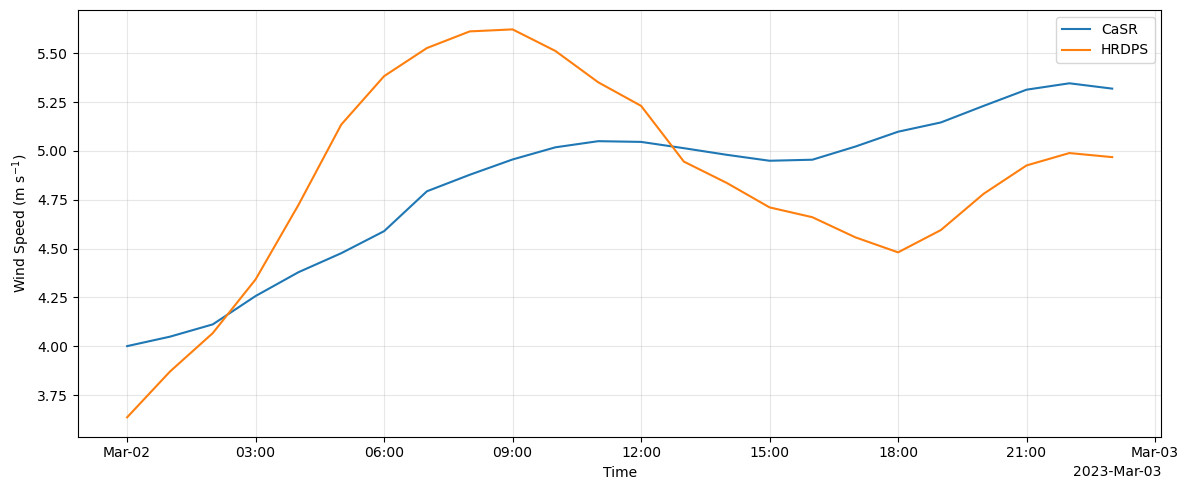

In [ ]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

mean_CaSR.plot(
    ax=ax,
    label='CaSR',
    linewidth=1.5
)

mean_HRDPS.plot(
    ax=ax,
    label='HRDPS',
    linewidth=1.5
)

ax.set_xlabel('Time')
ax.set_ylabel('Spatially Mean Wind Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


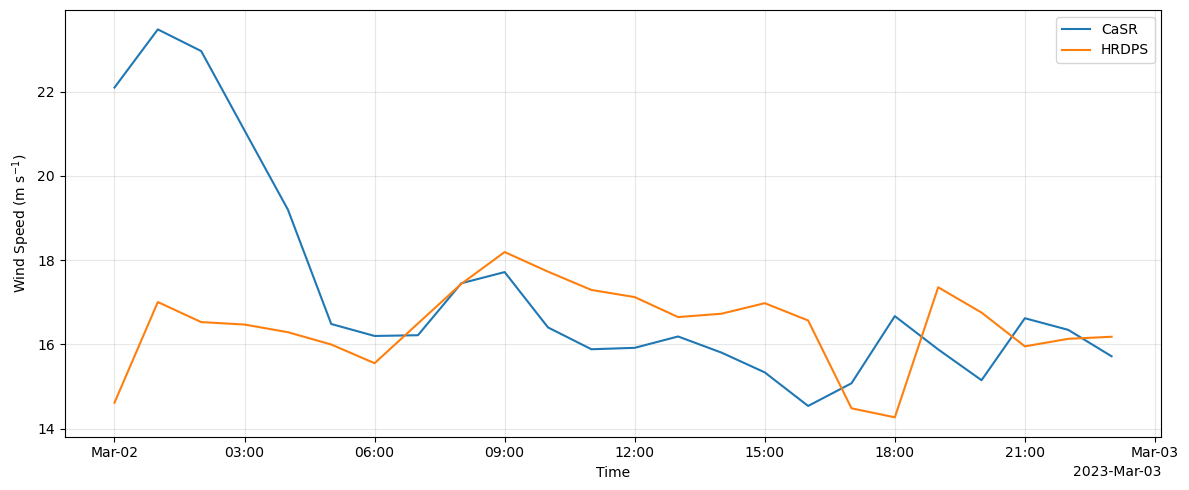

In [8]:
# visualize

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

max_CaSR.plot(
    ax=ax,
    label='CaSR',
    linewidth=1.5
)

max_HRDPS.plot(
    ax=ax,
    label='HRDPS',
    linewidth=1.5
)

ax.set_xlabel('Time')
ax.set_ylabel('Wind Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


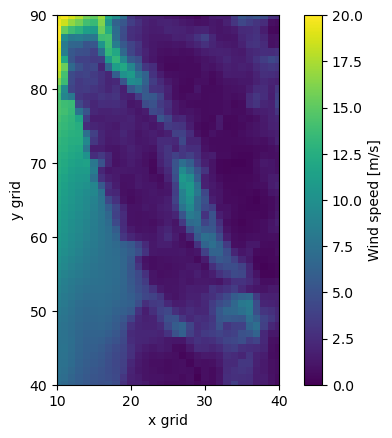

In [14]:
# CaSR pcolor 

speed_min=0
speed_max=20

plt.imshow(wind_CaSR.isel(time_counter=1).squeeze(), origin="lower",vmin=speed_min,vmax=speed_max)
plt.xlim(10, 40)   # 显示的 x 格点范围
plt.ylim(40, 90)   # 显示的 y 格点范围
plt.colorbar(label="Wind speed [m/s]")
plt.xlabel("x grid")
plt.ylabel("y grid")
plt.show()

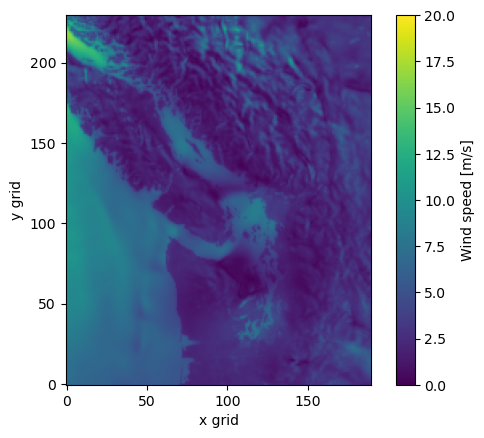

In [15]:
# HRDPS pcolor 

plt.imshow(wind_HRDPS.isel(time_counter=1).squeeze(), origin="lower",vmin=speed_min,vmax=speed_max)
plt.colorbar(label="Wind speed [m/s]")
plt.xlabel("x grid")
plt.ylabel("y grid")
plt.show()

## Surface Velocity

In [ ]:
# path

path_CaSR_u='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_CaSR_v='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'



Maximum longitude difference:
0.03588104248046875
Maximum latitude difference:
0.037761688232421875

Processing 2023-03-02
HRDPS U file: /results2/SalishSea/nowcast-green.202111/02mar23/SalishSea_1h_20230302_20230302_grid_U.nc
HRDPS V file: /results2/SalishSea/nowcast-green.202111/02mar23/SalishSea_1h_20230302_20230302_grid_V.nc
CaSR time steps:  9
HRDPS time steps: 24


ValueError: 2023-03-02: CaSR has 9 time steps, but HRDPS has 24 time steps.

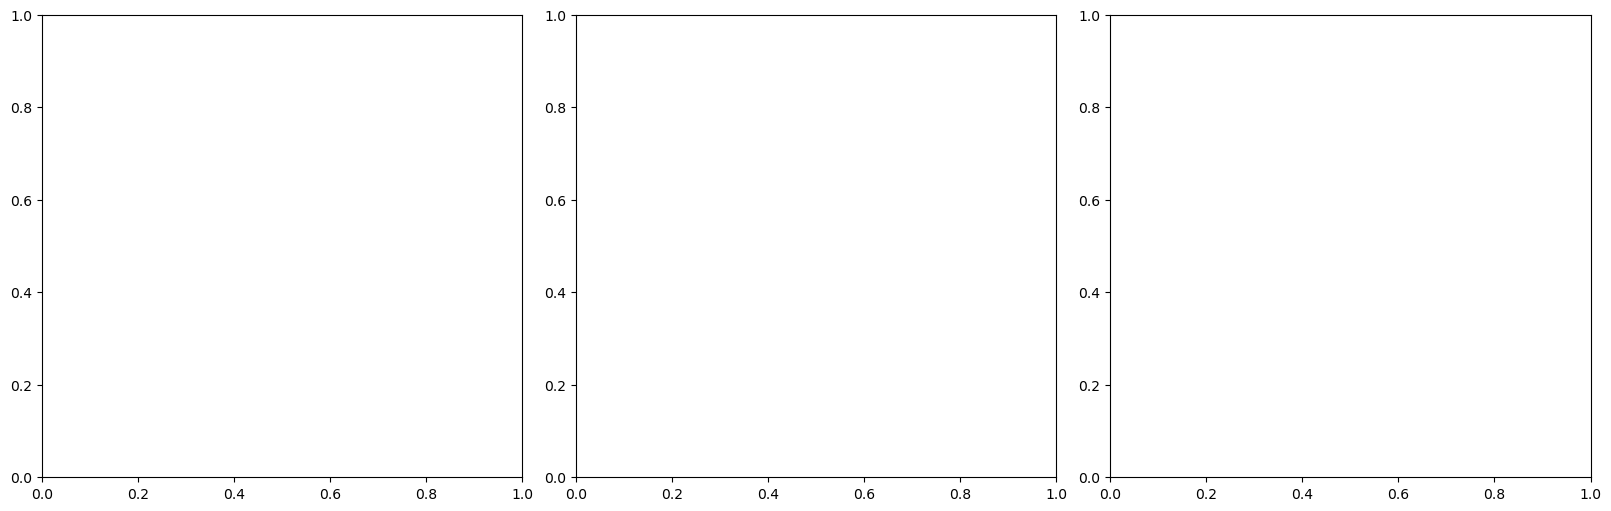

In [1]:
# imports
# --------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


# CaSR monthly files
# ------------------

path_CaSR_u = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_U.nc"
)

path_CaSR_v = (
    "/ocean/jqiu/results/CaSR/00mar23/"
    "SalishSea_1h_20230301_20230331_grid_V.nc"
)


# Dates to compare
# ----------------

dates = ["2023-03-02", "2023-03-16", "2023-03-31"]


def hrdps_file_path(date_string, grid):
    """
    Construct the HRDPS daily file path.

    Parameters
    ----------
    date_string : str
        Date formatted as YYYY-MM-DD.
    grid : str
        Either "U" or "V".
    """
    date = np.datetime64(date_string)
    compact_date = np.datetime_as_string(date, unit="D").replace("-", "")
    folder_date = compact_date[6:8] + "mar23"

    return (
        f"/results2/SalishSea/nowcast-green.202111/{folder_date}/"
        f"SalishSea_1h_{compact_date}_{compact_date}_grid_{grid}.nc"
    )


# Open CaSR monthly datasets
# --------------------------

ds_CaSR_u = xr.open_dataset(path_CaSR_u)
ds_CaSR_v = xr.open_dataset(path_CaSR_v)

u_CaSR = ds_CaSR_u["vozocrtx"].isel(depthu=0)
v_CaSR = ds_CaSR_v["vomecrty"].isel(depthv=0)


# Check horizontal coordinates
# ----------------------------

lon_u = ds_CaSR_u["nav_lon"]
lat_u = ds_CaSR_u["nav_lat"]

lon_v = ds_CaSR_v["nav_lon"]
lat_v = ds_CaSR_v["nav_lat"]

print("Maximum longitude difference:")
print(float(np.nanmax(np.abs(lon_u.values - lon_v.values))))

print("Maximum latitude difference:")
print(float(np.nanmax(np.abs(lat_u.values - lat_v.values))))


# Create scatter plots
# --------------------

fig, axes = plt.subplots(
    1,
    len(dates),
    figsize=(16, 5),
    constrained_layout=True,
)

rmse_results = {}

for ax, date_string in zip(axes, dates):

    # Select the complete day from the monthly CaSR files.
    # The upper limit is exclusive, so it is set to the next day.
    start_time = np.datetime64(date_string)
    end_time = start_time + np.timedelta64(1, "D")

    u_CaSR_day = u_CaSR.sel(
        time_counter=slice(start_time, end_time - np.timedelta64(1, "ns"))
    )
    v_CaSR_day = v_CaSR.sel(
        time_counter=slice(start_time, end_time - np.timedelta64(1, "ns"))
    )

    # Open corresponding HRDPS daily files
    file_HRDPS_u = hrdps_file_path(date_string, "U")
    file_HRDPS_v = hrdps_file_path(date_string, "V")

    print(f"\nProcessing {date_string}")
    print(f"HRDPS U file: {file_HRDPS_u}")
    print(f"HRDPS V file: {file_HRDPS_v}")

    if not Path(file_HRDPS_u).exists():
        raise FileNotFoundError(file_HRDPS_u)

    if not Path(file_HRDPS_v).exists():
        raise FileNotFoundError(file_HRDPS_v)

    with (
        xr.open_dataset(file_HRDPS_u) as ds_HRDPS_u,
        xr.open_dataset(file_HRDPS_v) as ds_HRDPS_v,
    ):
        u_HRDPS_day = ds_HRDPS_u["vozocrtx"].isel(depthu=0).load()
        v_HRDPS_day = ds_HRDPS_v["vomecrty"].isel(depthv=0).load()

    # Confirm that the expected hourly records were selected
    n_CaSR = u_CaSR_day.sizes["time_counter"]
    n_HRDPS = u_HRDPS_day.sizes["time_counter"]

    print(f"CaSR time steps:  {n_CaSR}")
    print(f"HRDPS time steps: {n_HRDPS}")

    if n_CaSR != n_HRDPS:
        raise ValueError(
            f"{date_string}: CaSR has {n_CaSR} time steps, "
            f"but HRDPS has {n_HRDPS} time steps."
        )

    # Assign the CaSR time coordinates to HRDPS.
    # This avoids alignment problems caused by slightly different
    # time-coordinate definitions in the two model outputs.
    u_HRDPS_day = u_HRDPS_day.assign_coords(
        time_counter=u_CaSR_day.time_counter
    )
    v_HRDPS_day = v_HRDPS_day.assign_coords(
        time_counter=v_CaSR_day.time_counter
    )

    # Calculate surface-current speed
    velocity_CaSR = np.sqrt(u_CaSR_day**2 + v_CaSR_day**2)
    velocity_HRDPS = np.sqrt(u_HRDPS_day**2 + v_HRDPS_day**2)

    # Convert all 24 hours and all grid cells into one-dimensional arrays
    casr = velocity_CaSR.values.ravel()
    hrdps = velocity_HRDPS.values.ravel()

    # Retain locations where both datasets are finite
    valid = np.isfinite(casr) & np.isfinite(hrdps)

    casr_valid = casr[valid]
    hrdps_valid = hrdps[valid]

    if casr_valid.size == 0:
        raise ValueError(f"No valid paired data found for {date_string}.")

    # Statistics
    difference = hrdps_valid - casr_valid

    rmse = np.sqrt(np.mean(difference**2))
    bias = np.mean(difference)
    correlation = np.corrcoef(casr_valid, hrdps_valid)[0, 1]

    rmse_results[date_string] = rmse

    # Scatter plot
    ax.scatter(
        casr_valid,
        hrdps_valid,
        s=3,
        alpha=0.2,
        edgecolors="none",
    )

    # 1:1 line
    lower = 0
    upper = 4

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        color="k",
        label="1:1 line",
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(r"CaSR velocity (m s$^{-1}$)")
    ax.set_ylabel(r"HRDPS velocity (m s$^{-1}$)")

    ax.set_title(
        f"{date_string}\n"
        f"RMSE = {rmse:.4f}, bias = {bias:.4f}\n"
        f"r = {correlation:.3f}, N = {casr_valid.size:,}"
    )

    ax.grid(alpha=0.3)
    ax.legend()


fig.suptitle(
    "Surface-current speed comparison: CaSR versus HRDPS",
    fontsize=14,
)

plt.show()


# Print RMSE summary
# ------------------

print("\nRMSE summary")
for date_string, rmse in rmse_results.items():
    print(f"{date_string}: {rmse:.6f} m/s")


# Close monthly datasets
# ----------------------

ds_CaSR_u.close()
ds_CaSR_v.close()

In [2]:
print(u_CaSR.shape, v_CaSR.shape)
print(u_CaSR.dims, v_CaSR.dims)

(33, 898, 398) (33, 898, 398)
('time_counter', 'y', 'x') ('time_counter', 'y', 'x')


In [ ]:
# path

path_CaSR_u='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
path_CaSR_v='/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt



# ---------------------------------------------------------
# Paths 
# ---------------------------------------------------------

date_dir = "02mar23"
date_file = "20230301"

casr_dir = f"/ocean/jqiu/results/CaSR/{date_dir}"
hrdps_dir = f"/results2/SalishSea/nowcast-green.202111/{date_dir}"

casr_u_path = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
casr_v_path = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'


hrdps_u_path = f"{hrdps_dir}/SalishSea_1h_{date_file}_{date_file}_grid_U.nc"
hrdps_v_path = f"{hrdps_dir}/SalishSea_1h_{date_file}_{date_file}_grid_V.nc"

variable_u='vozocrtx'
variable_v='vomecrty'

# Plot every 8th model point
quiver_stride = 8

In [ ]:
# load data

CaSR_u=xr.open_dataset(casr_u_path)
CaSR_u=CaSR_u[variable_u].isel(time_counter=32,depthu=0)
CaSR_v=xr.open_dataset(casr_v_path)
CaSR_v=CaSR_v[variable_v].isel(time_counter=32,depthv=0)

HRDPS_u=xr.open_dataset(hrdps_u_path)
HRDPS_u=HRDPS_u[variable_u].isel(time_counter=7,depthu=0)
HRDPS_v=xr.open_dataset(hrdps_v_path)
HRDPS_v=HRDPS_v[variable_v].isel(time_counter=7,depthv=0)

# calculate the difference

difference_u=CaSR_u-HRDPS_u
difference_v=CaSR_v-HRDPS_v

CaSR_speed = np.hypot(CaSR_u, CaSR_v)
HRDPS_speed = np.hypot(HRDPS_u, HRDPS_v)

difference_speed = np.hypot(difference_u,difference_v)

# grid

nj, ni = CaSR_u.shape

i_grid, j_grid = np.meshgrid(np.arange(ni),np.arange(nj))

s = np.s_[::quiver_stride, ::quiver_stride]

i_q = i_grid[s]
j_q = j_grid[s]
